# MICROBENCH: Benching latency and energy usage in dl operations

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## BATCH SIZE

In [13]:
CSV_FILE = "./tmp/linear_latency_results_batch_size.csv"
METRIC = "batch_size"
MAX_METRIC_VALUE = 300

df = pd.read_csv(CSV_FILE)
df

,batch_size,Avg Latency (ms)
0,1,0.084410
1,2,0.076278
2,3,0.091475
3,4,0.092006
4,5,0.093056
...,...,...
251,252,0.476893
252,253,0.475795
253,254,0.476902
254,255,0.477136


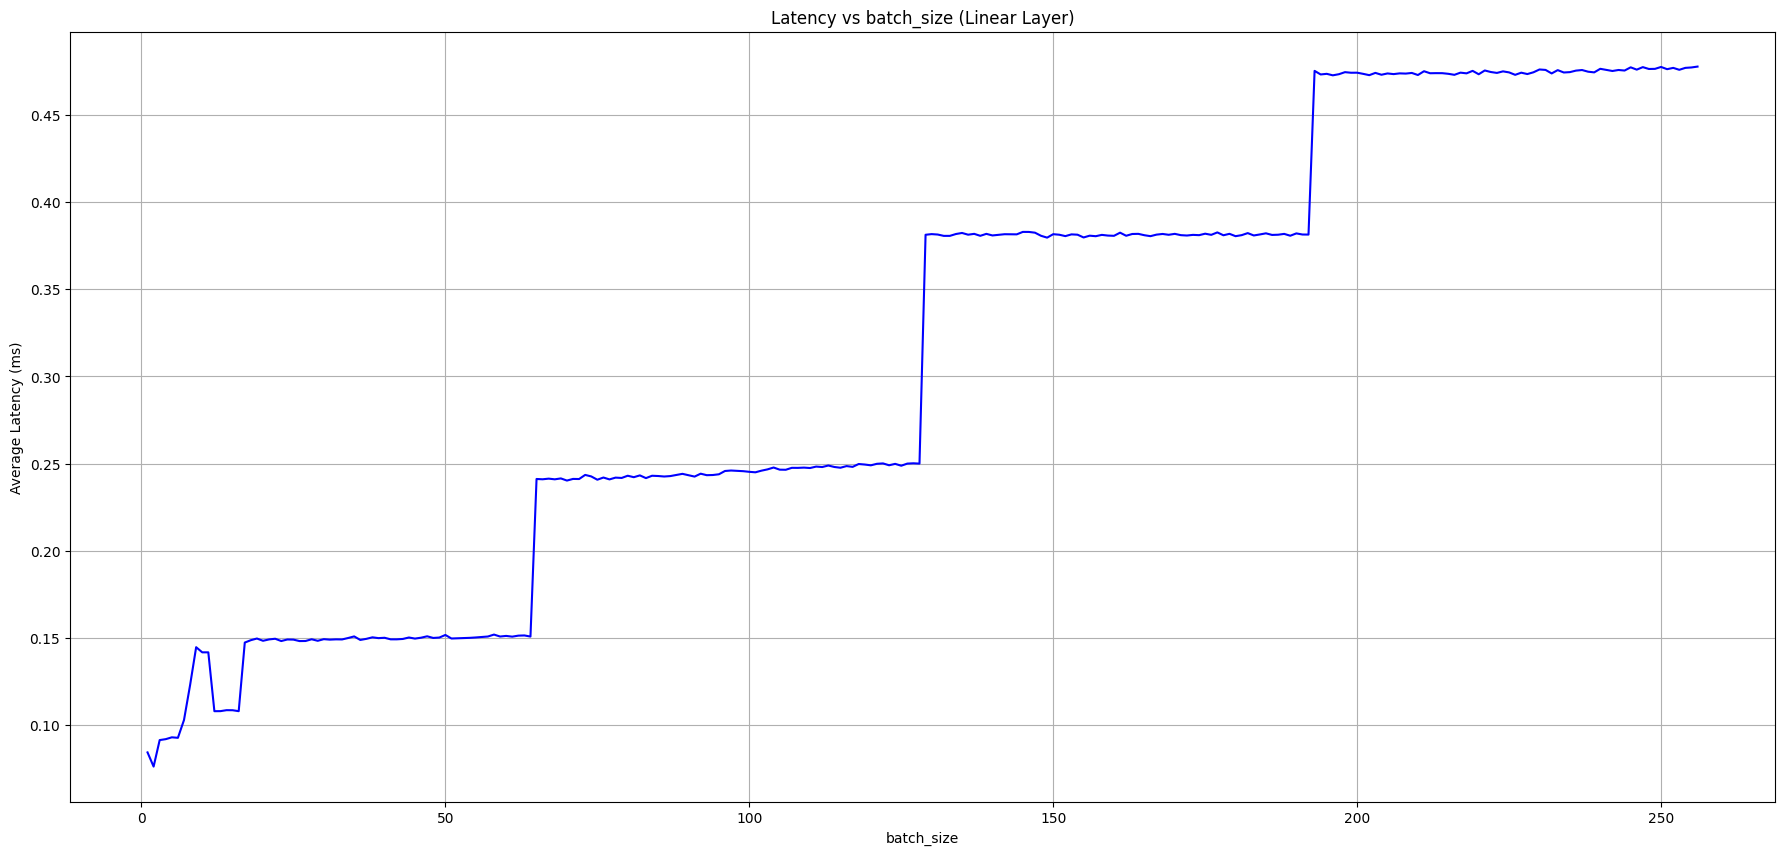

In [15]:
df = df[df[METRIC] < MAX_METRIC_VALUE]
metric = df[METRIC].values
avg_latencies = df["Avg Latency (ms)"].values


plt.figure(figsize=(22, 10))
plt.plot(metric, avg_latencies, linestyle='-', color='b')
plt.xlabel(METRIC)
plt.ylabel("Average Latency (ms)")
plt.title(f"Latency vs {METRIC} (Linear Layer)")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


## SEQUENCE LENGTH

In [ ]:
CSV_FILE = "./tmp/linear_latency_results_seq_length.csv"
METRIC = "seq_len"
MAX_METRIC_VALUE = 1000

df = pd.read_csv(CSV_FILE)
df

,hidden_dim,ffn_dim,seq_len,batch_size,avg_latency_ms
0,4096,11008,1,1,0.071037
1,4096,11008,2,1,0.075699
2,4096,11008,3,1,0.092816
3,4096,11008,4,1,0.091699
4,4096,11008,5,1,0.091709
...,...,...,...,...,...
506,4096,11008,507,1,0.931373
507,4096,11008,508,1,0.930589
508,4096,11008,509,1,0.932566
509,4096,11008,510,1,0.931936


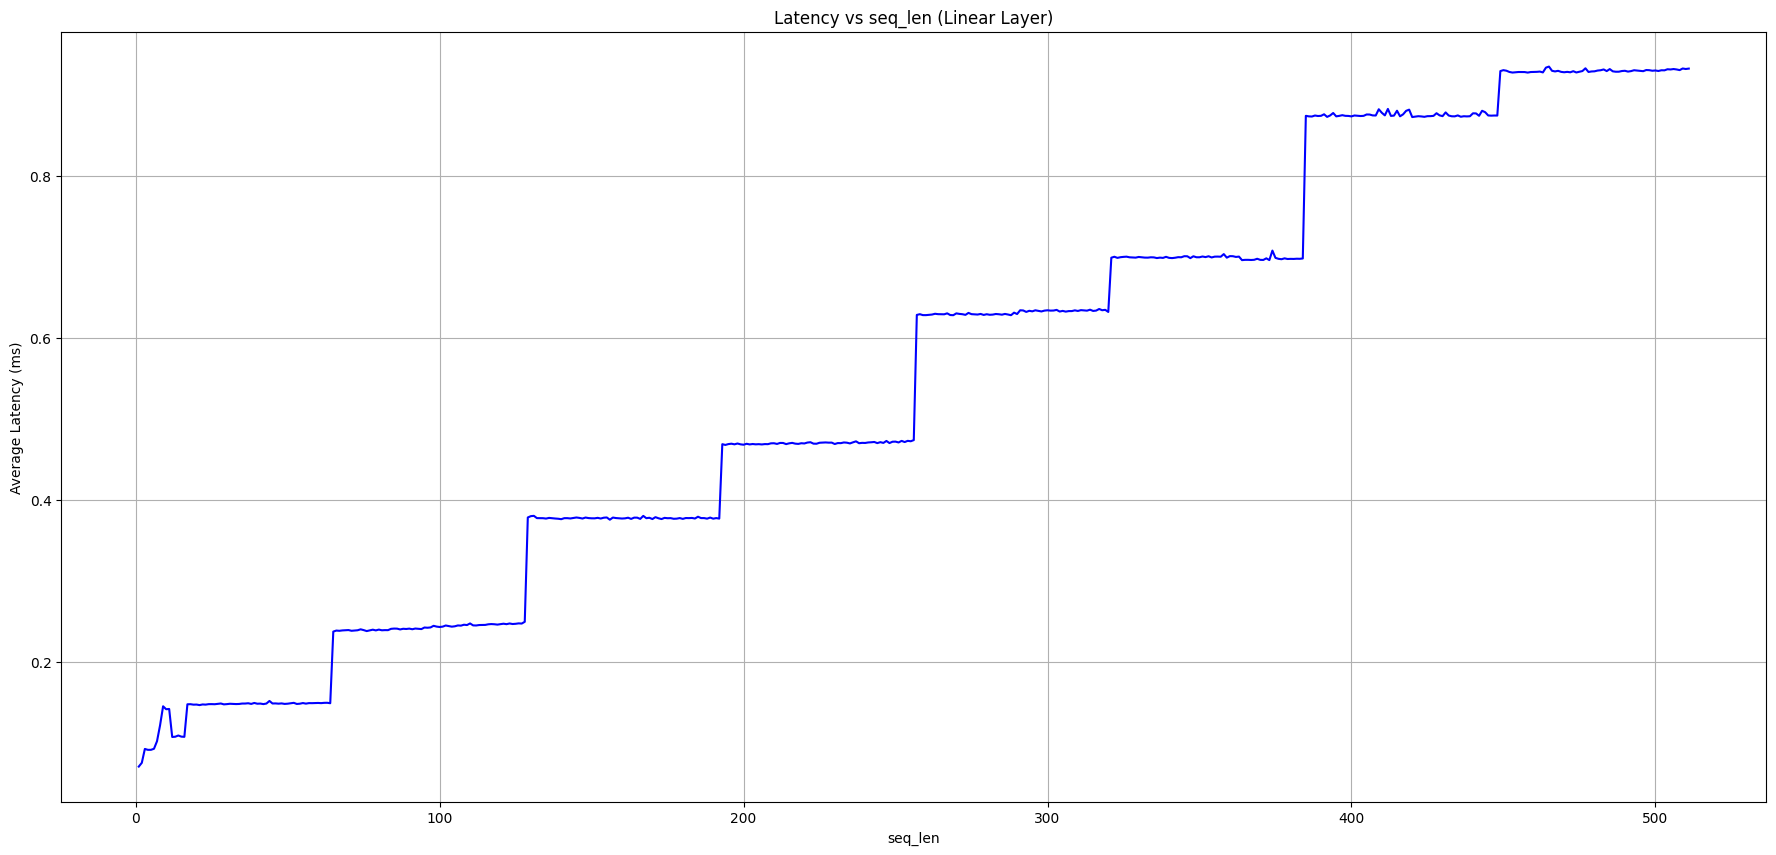

In [18]:
df = df[df[METRIC] < MAX_METRIC_VALUE]
metric = df[METRIC].values
avg_latencies = df["avg_latency_ms"].values


plt.figure(figsize=(22, 10))
plt.plot(metric, avg_latencies, linestyle='-', color='b')
plt.xlabel(METRIC)
plt.ylabel("Average Latency (ms)")
plt.title(f"Latency vs {METRIC} (Linear Layer)")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


## HIDDEN DIM

In [6]:
CSV_FILE = "./tmp/linear_latency_results_hidden_dims.csv"
METRIC = "hidden_dim"
MAX_METRIC_VALUE = 100_000

df = pd.read_csv(CSV_FILE)
df

,hidden_dim,ffn_dim,seq_len,batch_size,avg_latency_ms
0,1,11008,1,1,0.039891
1,2,11008,1,1,0.032861
2,3,11008,1,1,0.032576
3,4,11008,1,1,0.032797
4,5,11008,1,1,0.035216
...,...,...,...,...,...
16378,16379,11008,1,1,0.241942
16379,16380,11008,1,1,0.242275
16380,16381,11008,1,1,0.242102
16381,16382,11008,1,1,0.242806


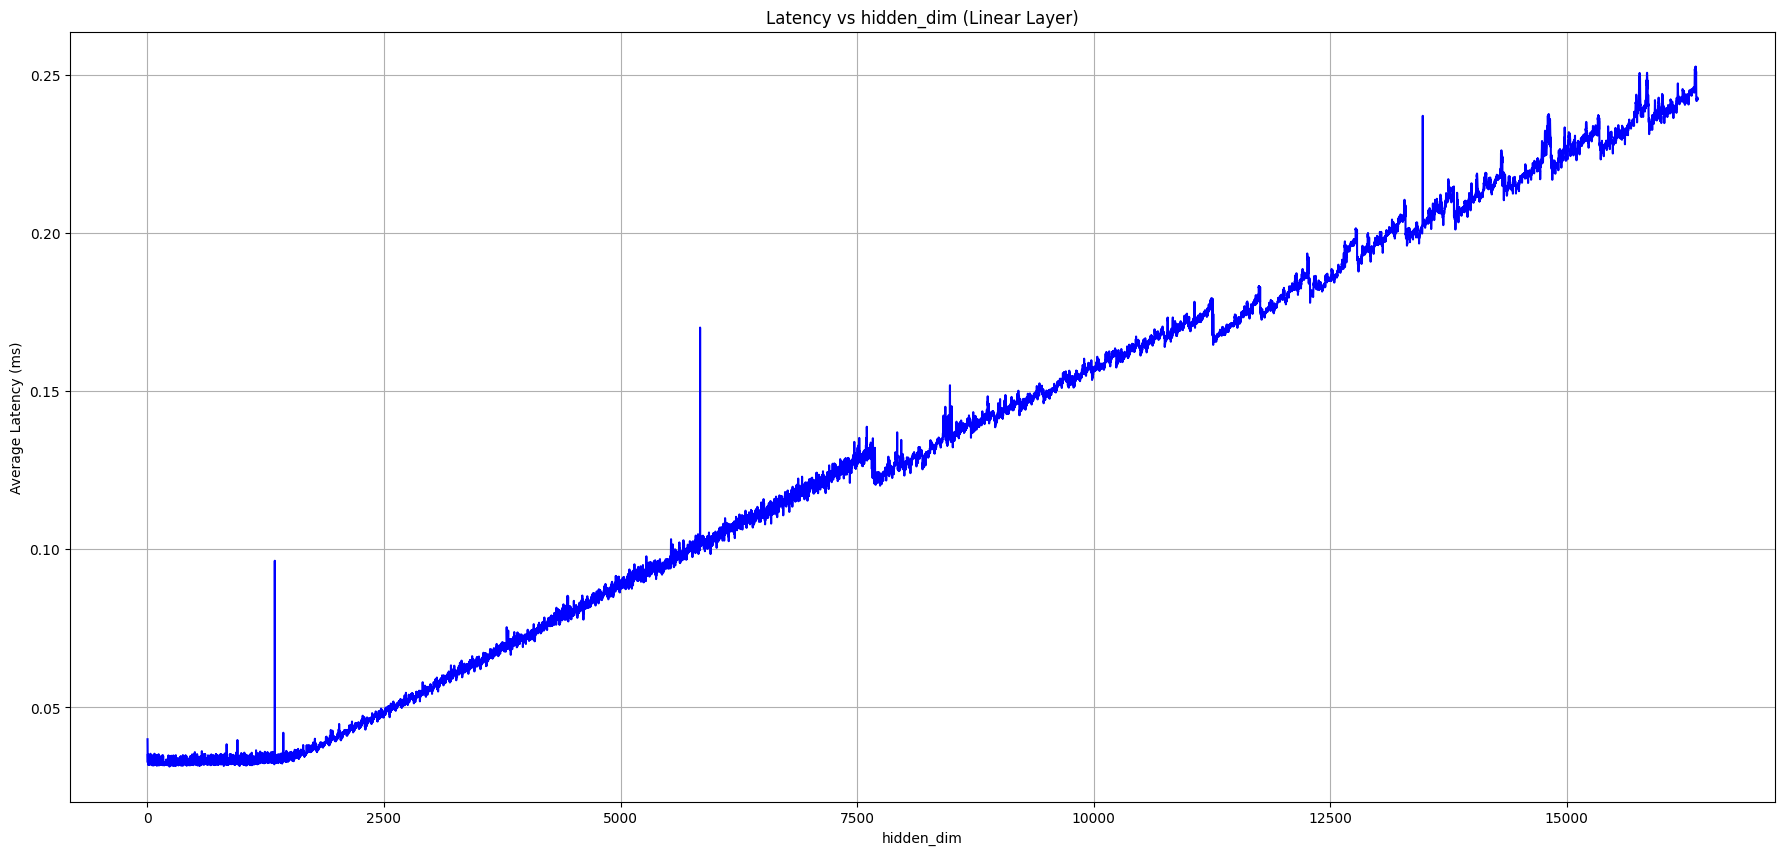

In [7]:
MAX_METRIC_VALUE = 500000

metric = df[METRIC].values
avg_latencies = df["avg_latency_ms"].values


plt.figure(figsize=(22, 10))
plt.plot(metric, avg_latencies, linestyle='-', color='b')
plt.xlabel(METRIC)
plt.ylabel("Average Latency (ms)")
plt.title(f"Latency vs {METRIC} (Linear Layer)")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


## FFN DIM

In [27]:
CSV_FILE = "./tmp/linear_latency_results_ffn_dims.csv"
METRIC = "ffn_dim"
MAX_METRIC_VALUE = 100_000

df = pd.read_csv(CSV_FILE)
df

,hidden_dim,ffn_dim,seq_len,batch_size,avg_latency_ms
0,4096,1,1,1,0.036688
1,4096,2,1,1,0.034627
2,4096,3,1,1,0.034336
3,4096,4,1,1,0.033814
4,4096,5,1,1,0.034336
...,...,...,...,...,...
65530,4096,65531,1,1,0.346966
65531,4096,65532,1,1,0.346064
65532,4096,65533,1,1,0.346704
65533,4096,65534,1,1,0.346022


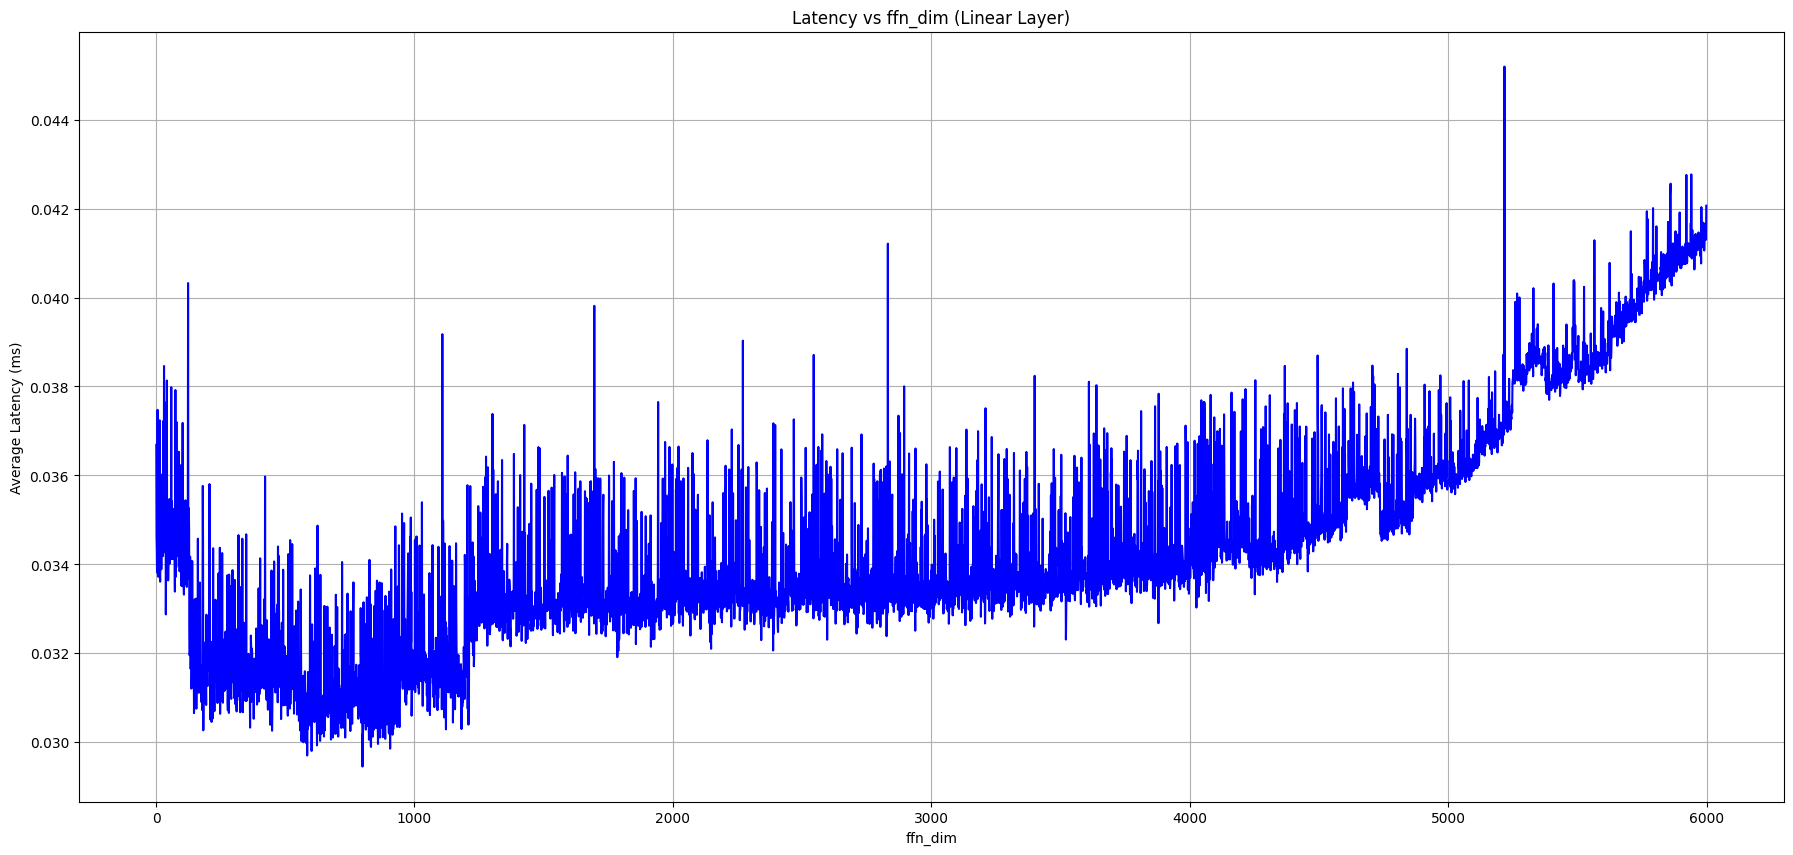

In [28]:
MAX_METRIC_VALUE = 6000
df = df[df[METRIC] < MAX_METRIC_VALUE]
metric = df[METRIC].values
avg_latencies = df["avg_latency_ms"].values


plt.figure(figsize=(22, 10))
plt.plot(metric, avg_latencies, linestyle='-', color='b')
plt.xlabel(METRIC)
plt.ylabel("Average Latency (ms)")
plt.title(f"Latency vs {METRIC} (Linear Layer)")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


## TODO
- Varing metrics
- See if varitaion of kernel at each jump (plot max used kernel per metric ?)
- mesure energy usage nvml
- Try attention layer


In [1]:
hidden_dim = 4096  # Input dimension
ffn_dim = 11008  # Output dimension
batch_size = 1  # Batch size
seq_len = 1  # Sequence length
dtype_size = 4  # Size of float32 in bytes

total_memory = ((hidden_dim * ffn_dim) + (batch_size * seq_len * hidden_dim) + (batch_size * seq_len * ffn_dim)) * dtype_size
print(f"Total memory required for the model: {total_memory/(1024*1024):.2f} MB")

# L2 cache size 50 MB
l2_cache_size = 50 * 1024 * 1024  # MB to bytes

max_hidden_dim = ((l2_cache_size / dtype_size) - (batch_size * seq_len * ffn_dim)) / (ffn_dim + batch_size * seq_len)
print(f"Maximum hidden dimension that fits in L2 cache: {max_hidden_dim:.2f}")

max_ffn_dim = ((l2_cache_size / dtype_size) - (batch_size * seq_len * hidden_dim)) / (hidden_dim + batch_size * seq_len)
print(f"Maximum FFN dimension that fits in L2 cache: {max_ffn_dim:.2f}")

max_batch_size = (l2_cache_size / dtype_size - (hidden_dim * ffn_dim)) / (seq_len * (hidden_dim + ffn_dim))
print(f"Maximum batch size that fits in L2 cache: {max_batch_size:.2f}")

max_seq_len = (l2_cache_size / dtype_size - (hidden_dim * ffn_dim)) / (batch_size * (hidden_dim + ffn_dim))
print(f"Maximum sequence length that fits in L2 cache: {max_seq_len:.2f}")



Total memory required for the model: 172.06 MB
Maximum hidden dimension that fits in L2 cache: 1189.59
Maximum FFN dimension that fits in L2 cache: 3198.22
Maximum batch size that fits in L2 cache: -2117.42
Maximum sequence length that fits in L2 cache: -2117.42


In [2]:
max_hidden_dim_found = 1500  # Input dimension
max_ffn_dim_found = 4100  # Output dimension
batch_size = 1  # Batch size
seq_len = 1  # Sequence length
dtype_size = 4  # Size of float32 in bytes

total_memory_hidden_dim = ((max_hidden_dim_found * ffn_dim) + (batch_size * seq_len * max_hidden_dim_found) + (batch_size * seq_len * ffn_dim)) * dtype_size
total_memory_ffn_dim = ((hidden_dim * max_ffn_dim_found) + (batch_size * seq_len * hidden_dim) + (batch_size * seq_len * max_ffn_dim_found)) * dtype_size
print(f"Max cached memory according to hidden dim : {total_memory_hidden_dim/(1024*1024):.2f} MB")
print(f"Max cached memory according to ffn dim : {total_memory_ffn_dim/(1024*1024):.2f} MB")




Max cached memory according to hidden dim : 63.04 MB
Max cached memory according to ffn dim : 64.09 MB


In [3]:
hidden_dim = 4096  # Input dimension
ffn_dim = 11008  # Output dimension
batch_size = 1  # Batch size
seq_len = 1  # Sequence length
dtype_size = 4  # Size of float32 in bytes

total_memory_cached = (hidden_dim * ffn_dim) * dtype_size
print(f"Total memory required for the model: {total_memory/(1024*1024):.2f} MB")

# L2 cache size 50 MB
l2_cache_size = 50 * 1024 * 1024  # MB to bytes

max_hidden_dim = l2_cache_size / (ffn_dim * dtype_size)
print(f"Maximum hidden dimension that fits in L2 cache: {max_hidden_dim:.2f}")

max_ffn_dim = l2_cache_size / (hidden_dim * dtype_size)
print(f"Maximum FFN dimension that fits in L2 cache: {max_ffn_dim:.2f}")




Total memory required for the model: 172.06 MB
Maximum hidden dimension that fits in L2 cache: 1190.70
Maximum FFN dimension that fits in L2 cache: 3200.00


In [5]:
50 *1024*1024 / (4096 * 4)  # 45 MB L2 cache size, hidden_dim = 4096, dtype_size = 4 bytes

3200.0

In [7]:
45 *1024*1024 / (11008 * 4)

1071.6279069767443

## Power trace

In [ ]:
import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-03-15-16-22.csv")
power_df

,time_ns,power_w,time_ms
0,290,119.327,0.000290
1,1964332,119.327,1.964332
2,2197397,119.327,2.197397
3,2360880,119.327,2.360880
4,2524174,119.327,2.524174
...,...,...,...
5195,840488058,291.391,840.488058
5196,840655412,291.391,840.655412
5197,840816695,291.391,840.816695
5198,840976589,291.391,840.976589


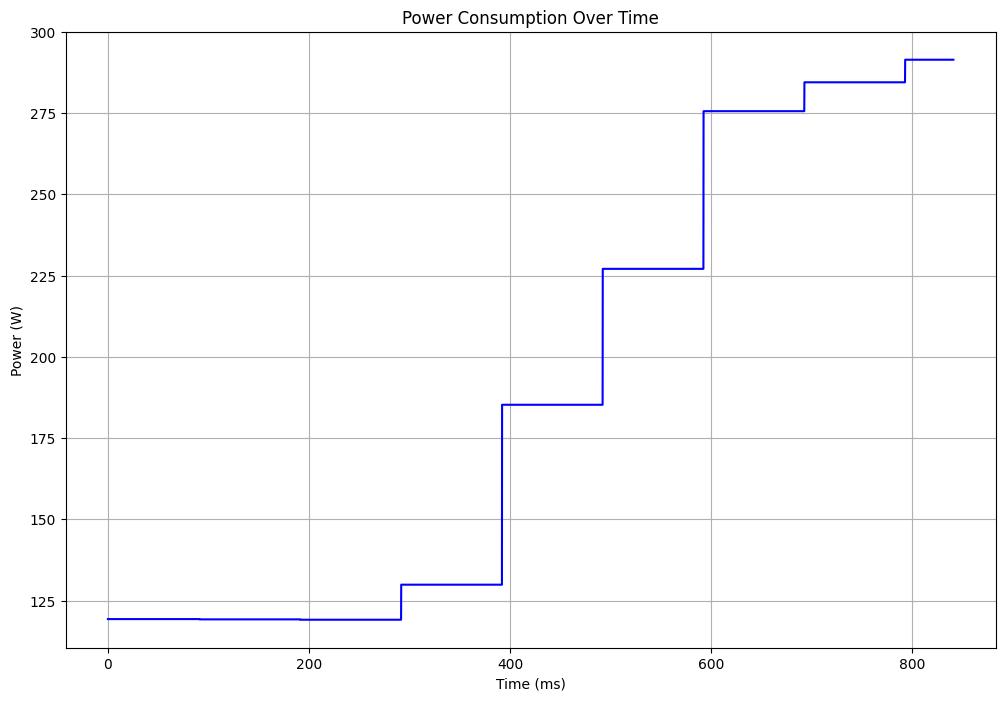

In [4]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

### Power Prefill phase

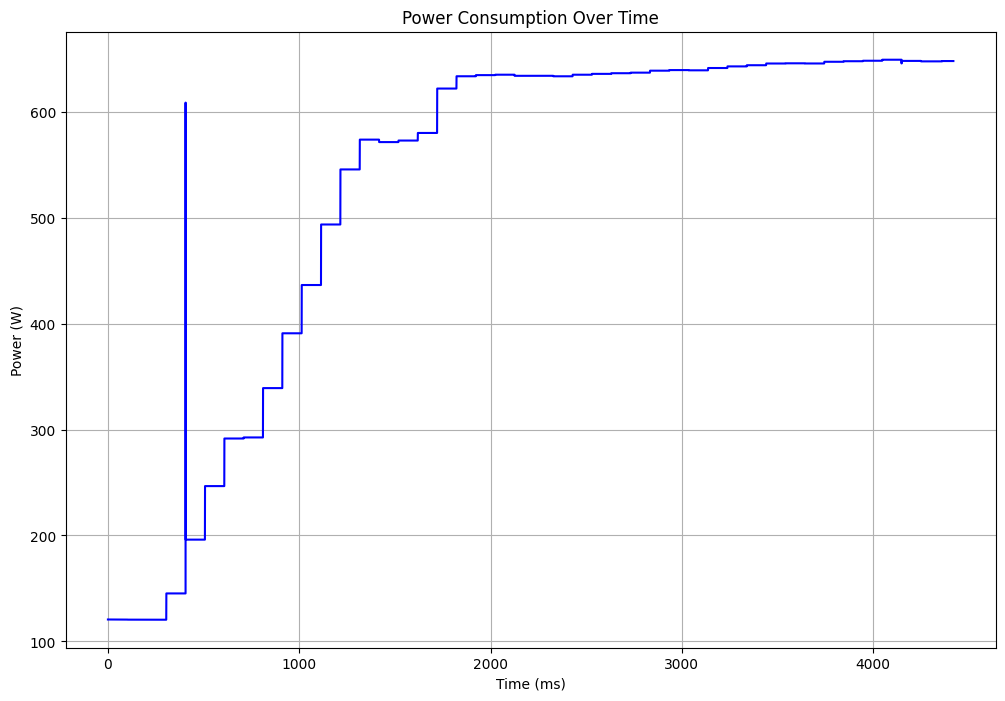

In [5]:
import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-03-15-47-41.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

['prefill', '1024.csv']
['prefill', '512.csv']
['prefill', '32.csv']
['prefill', '64.csv']
['prefill', '2048.csv']
['prefill', '4.csv']
['prefill', '3.csv']
['prefill', '256.csv']
['prefill', '128.csv']
['prefill', '2.csv']
['prefill', '7.csv']
['prefill', '10.csv']
['prefill', '8.csv']
['prefill', '16.csv']
['prefill', '5.csv']
['prefill', '1.csv']
['prefill', '9.csv']


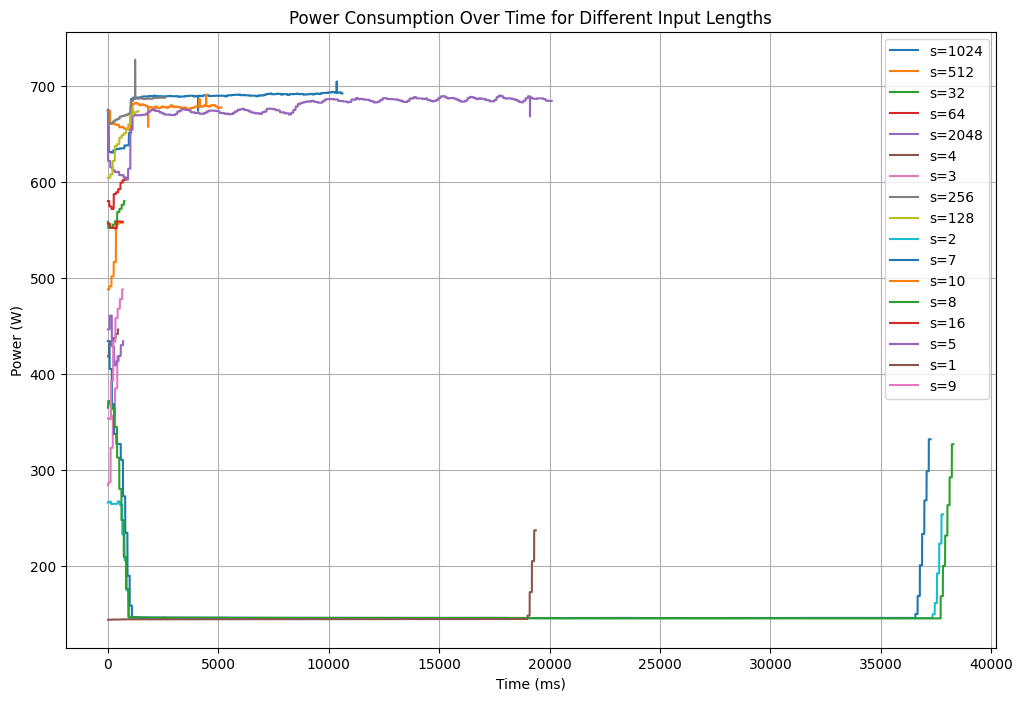

In [10]:
import os
plt.figure(figsize=(12, 8))
for file in os.listdir("./tmp/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        print(file.split("_s"))
        s = int(file.split("_s")[1].split(".")[0])
        power_df = pd.read_csv(f"./tmp/{file}")
        plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', label=f"s={s}")
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time for Different Input Lengths")
plt.legend()
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


['prefill', '3.csv']
['prefill', '5.csv']
['prefill', '10.csv']
['prefill', '512.csv']
['prefill', '64.csv']
['prefill', '16.csv']
['prefill', '1024.csv']
['prefill', '8.csv']
['prefill', '256.csv']
['prefill', '2048.csv']
['prefill', '4.csv']
['prefill', '128.csv']
['prefill', '2.csv']
['prefill', '9.csv']
['prefill', '1.csv']
['prefill', '32.csv']
['prefill', '7.csv']


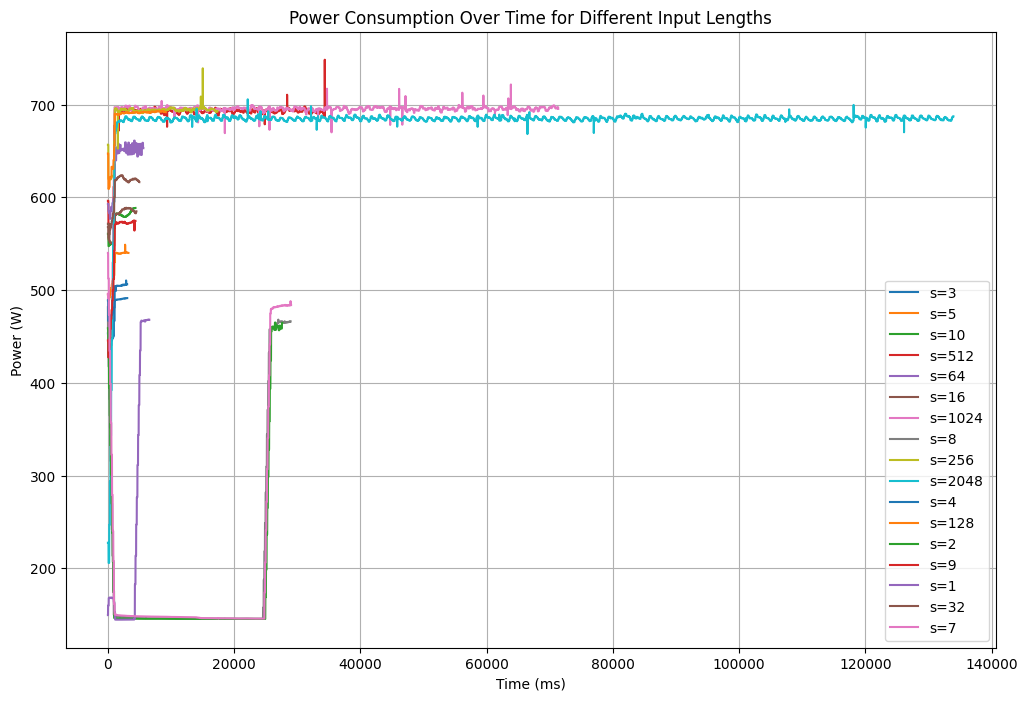

In [19]:
import os
plt.figure(figsize=(12, 8))
for file in os.listdir("./power_data/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        print(file.split("_s"))
        s = int(file.split("_s")[1].split(".")[0])
        power_df = pd.read_csv(f"./power_data/{file}")
        plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', label=f"s={s}")
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time for Different Input Lengths")
plt.legend()
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


['prefill', '195.csv']
['prefill', '196.csv']
['prefill', '193.csv']
['prefill', '191.csv']
['prefill', '194.csv']
['prefill', '199.csv']
['prefill', '198.csv']
['prefill', '192.csv']
['prefill', '197.csv']


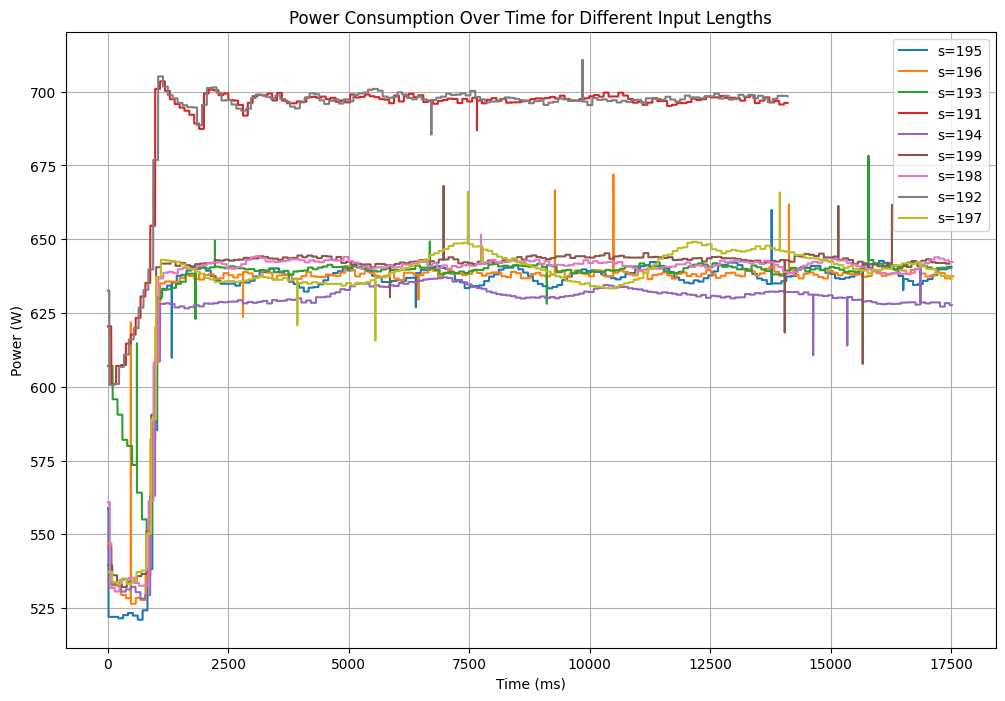

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        s = int(file.split("_s")[1].split(".")[0])
        if s > 190 and s < 200:
            print(file.split("_s"))
            power_df = pd.read_csv(f"./power_data2/{file}")
            plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', label=f"s={s}")
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time for Different Input Lengths")
plt.legend()
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


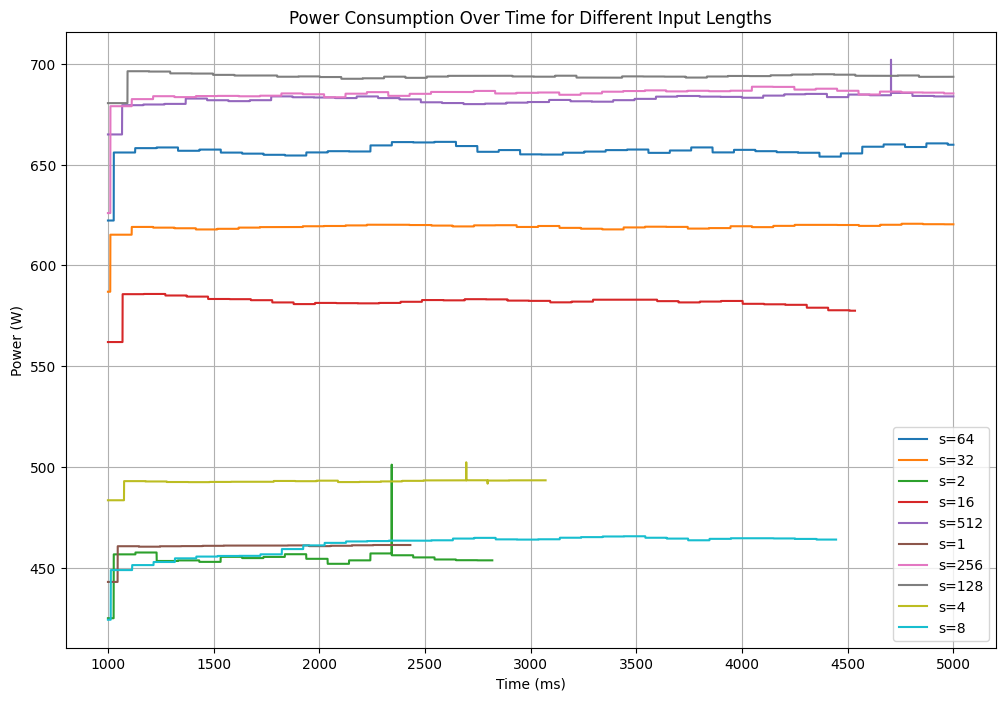

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        s = int(file.split("_s")[1].split(".")[0])
        if s in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1000]:
            power_df = pd.read_csv(f"./power_data2/{file}")
            x = power_df[(power_df["time_ms"] > 1000) & (power_df["time_ms"] < 5000)]["time_ms"]
            y = power_df[(power_df["time_ms"] > 1000) & (power_df["time_ms"] < 5000)]["power_w"]
            plt.plot(x, y, linestyle='-', label=f"s={s}")
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption for looping prefill phase Over Time for Different Input Lengths")
plt.legend()
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


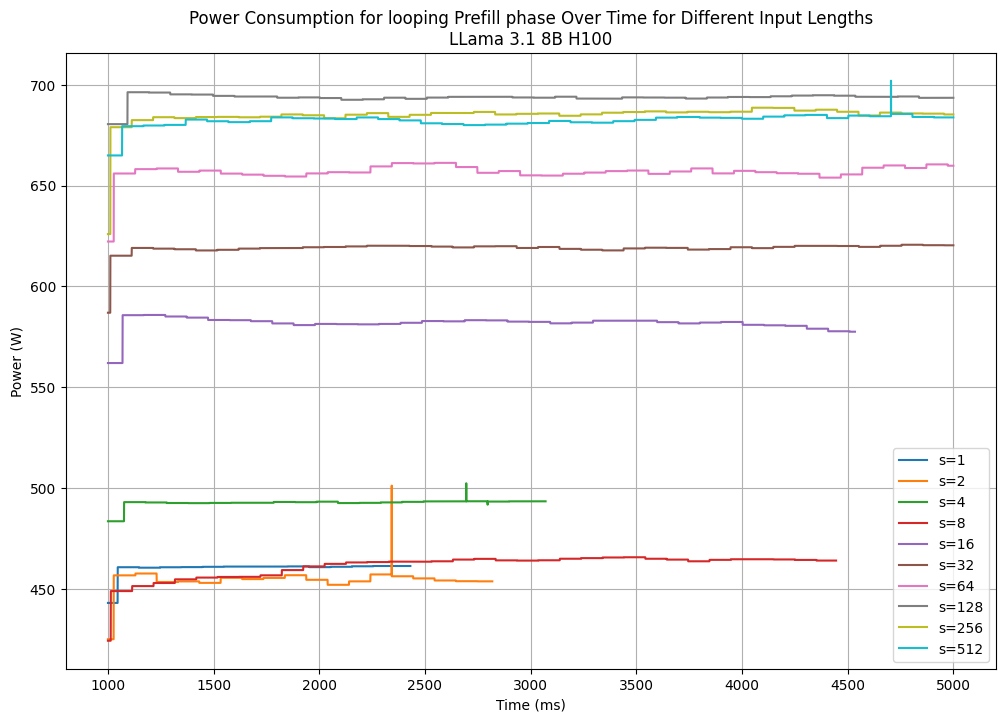

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
curves = []

for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        s = int(file.split("_s")[1].split(".")[0])
        if s in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1000]:
            power_df = pd.read_csv(f"./power_data2/{file}")
            x = power_df[(power_df["time_ms"] > 1000) & (power_df["time_ms"] < 5000)]["time_ms"]
            y = power_df[(power_df["time_ms"] > 1000) & (power_df["time_ms"] < 5000)]["power_w"]
            curves.append((s, x, y))

# Trier les courbes par ordre croissant de s
curves.sort(key=lambda tup: tup[0])

# Tracer après le tri
for s, x, y in curves:
    plt.plot(x, y, linestyle='-', label=f"s={s}")

plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption for looping Prefill phase Over Time for Different Input Lengths\nLLama 3.1 8B H100")
plt.legend()
plt.grid(True)
plt.show()


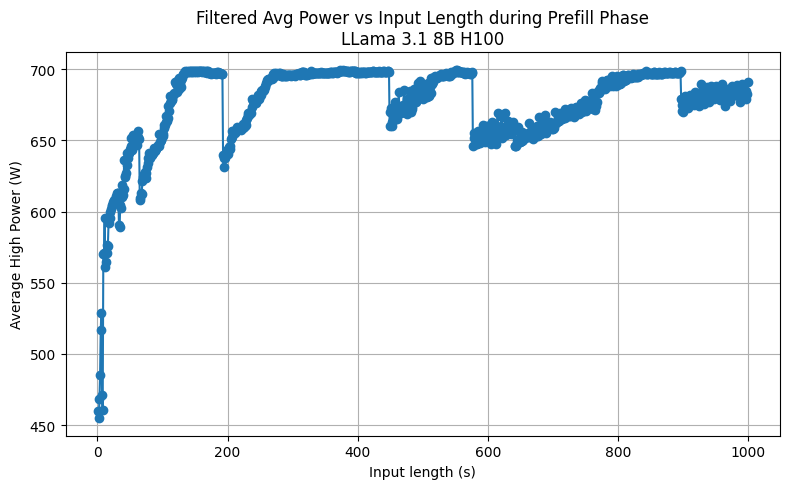

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt

threshold_ratio = 0.9  # Seuil de filtrage (90% du max)
input_lengths = []
avg_high_powers = []

for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        s = int(file.split("_s")[1].split(".")[0])
        power_df = pd.read_csv(f"./power_data2/{file}")

        max_power = power_df["power_w"].max()
        threshold = threshold_ratio * max_power

        # Ne garder que les puissances proches du max
        high_power_values = power_df[power_df["power_w"] >= threshold]["power_w"]

        if not high_power_values.empty:
            avg_power = high_power_values.mean()
            input_lengths.append(s)
            avg_high_powers.append(avg_power)

# Tri par longueur d'entrée
sorted_pairs = sorted(zip(input_lengths, avg_high_powers))
input_lengths, avg_high_powers = zip(*sorted_pairs)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(input_lengths, avg_high_powers, marker='o')
plt.xlabel("Input length (s)")
plt.ylabel("Average High Power (W)")
plt.title(f"Filtered Avg Power vs Input Length during Prefill Phase\nLLama 3.1 8B H100")
plt.grid(True)
plt.tight_layout()
plt.show()


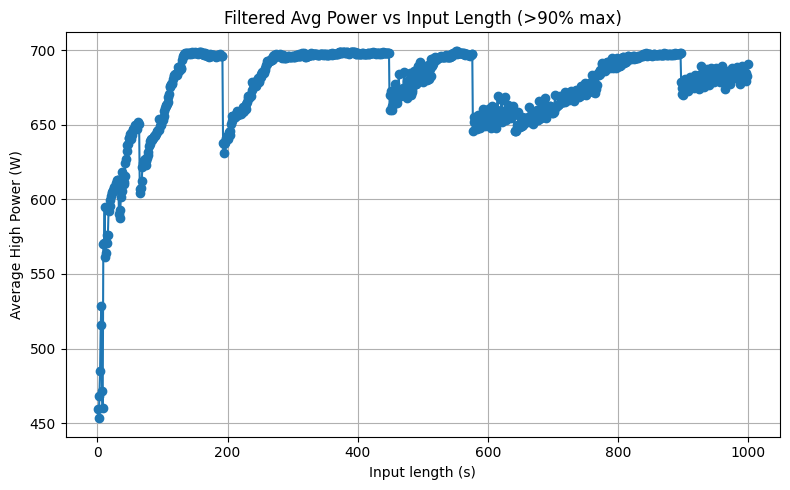

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

threshold_ratio = 0.9  # Seuil de filtrage (90% du max)
input_lengths = []
avg_high_powers = []

for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        s = int(file.split("_s")[1].split(".")[0])
        power_df = pd.read_csv(f"./power_data2/{file}")

        max_power = power_df["power_w"].iloc[-1]
        threshold = threshold_ratio * max_power

        # Ne garder que les puissances proches du max
        high_power_values = power_df[power_df["power_w"] >= threshold]["power_w"]

        if not high_power_values.empty:
            avg_power = high_power_values.mean()
            input_lengths.append(s)
            avg_high_powers.append(avg_power)

# Tri par longueur d'entrée
sorted_pairs = sorted(zip(input_lengths, avg_high_powers))
input_lengths, avg_high_powers = zip(*sorted_pairs)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(input_lengths, avg_high_powers, marker='o')
plt.xlabel("Input length (s)")
plt.ylabel("Average High Power (W)")
plt.title(f"Filtered Avg Power vs Input Length (>{int(threshold_ratio*100)}% max)")
plt.grid(True)
plt.tight_layout()
plt.show()


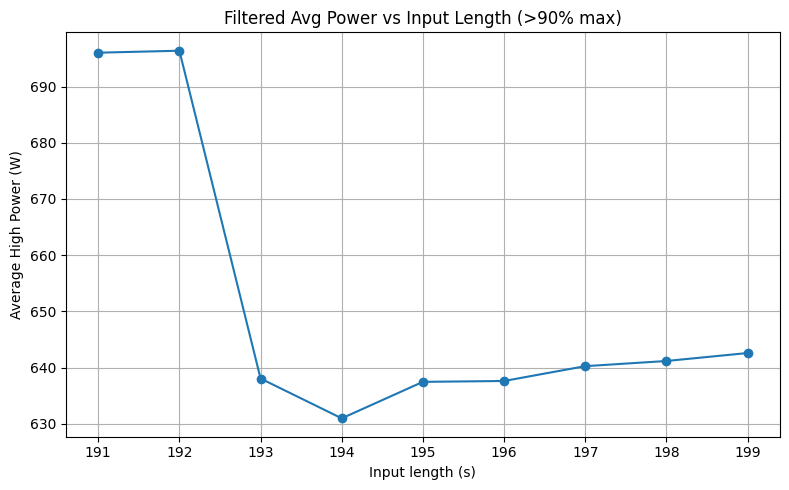

In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt

threshold_ratio = 0.9  # Seuil de filtrage (90% du max)
input_lengths = []
avg_high_powers = []

for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        s = int(file.split("_s")[1].split(".")[0])
        if s > 190 and s < 200:
            power_df = pd.read_csv(f"./power_data2/{file}")

            max_power = power_df["power_w"].iloc[-1]
            threshold = threshold_ratio * max_power

            # Ne garder que les puissances proches du max
            high_power_values = power_df[power_df["power_w"] >= threshold]["power_w"]

            if not high_power_values.empty:
                avg_power = high_power_values.mean()
                input_lengths.append(s)
                avg_high_powers.append(avg_power)

# Tri par longueur d'entrée
sorted_pairs = sorted(zip(input_lengths, avg_high_powers))
input_lengths, avg_high_powers = zip(*sorted_pairs)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(input_lengths, avg_high_powers, marker='o')
plt.xlabel("Input length (s)")
plt.ylabel("Average High Power (W)")
plt.title(f"Filtered Avg Power vs Input Length (>{int(threshold_ratio*100)}% max)")
plt.grid(True)
plt.tight_layout()
plt.show()


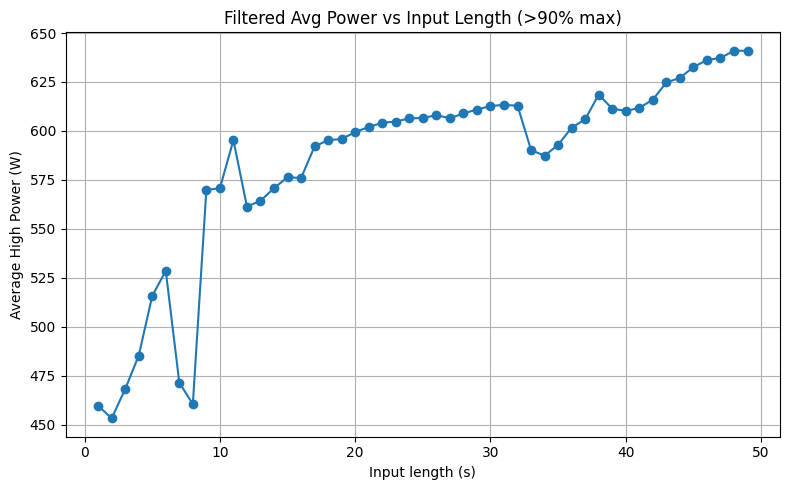

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

threshold_ratio = 0.9  # Seuil de filtrage (90% du max)
input_lengths = []
avg_high_powers = []

for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        s = int(file.split("_s")[1].split(".")[0])
        if s < 50:
            power_df = pd.read_csv(f"./power_data2/{file}")

            max_power = power_df["power_w"].iloc[-1]
            threshold = threshold_ratio * max_power

            # Ne garder que les puissances proches du max
            high_power_values = power_df[power_df["power_w"] >= threshold]["power_w"]

            if not high_power_values.empty:
                avg_power = high_power_values.mean()
                input_lengths.append(s)
                avg_high_powers.append(avg_power)

# Tri par longueur d'entrée
sorted_pairs = sorted(zip(input_lengths, avg_high_powers))
input_lengths, avg_high_powers = zip(*sorted_pairs)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(input_lengths, avg_high_powers, marker='o')
plt.xlabel("Input length (s)")
plt.ylabel("Average High Power (W)")
plt.title(f"Filtered Avg Power vs Input Length (>{int(threshold_ratio*100)}% max)")
plt.grid(True)
plt.tight_layout()
plt.show()


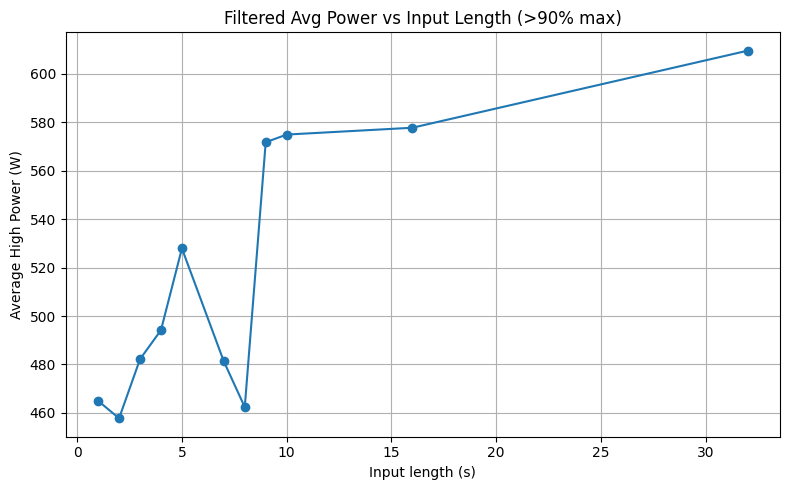

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

threshold_ratio = 0.9  # Seuil de filtrage (90% du max)
input_lengths = []
avg_high_powers = []

for file in os.listdir("./power_data/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        s = int(file.split("_s")[1].split(".")[0])
        if s < 50:
            power_df = pd.read_csv(f"./power_data/{file}")

            max_power = power_df["power_w"].iloc[-1]
            threshold = threshold_ratio * max_power

            # Ne garder que les puissances proches du max
            high_power_values = power_df[power_df["power_w"] >= threshold]["power_w"]

            if not high_power_values.empty:
                avg_power = high_power_values.mean()
                input_lengths.append(s)
                avg_high_powers.append(avg_power)

# Tri par longueur d'entrée
sorted_pairs = sorted(zip(input_lengths, avg_high_powers))
input_lengths, avg_high_powers = zip(*sorted_pairs)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(input_lengths, avg_high_powers, marker='o')
plt.xlabel("Input length (s)")
plt.ylabel("Average High Power (W)")
plt.title(f"Filtered Avg Power vs Input Length (>{int(threshold_ratio*100)}% max)")
plt.grid(True)
plt.tight_layout()
plt.show()


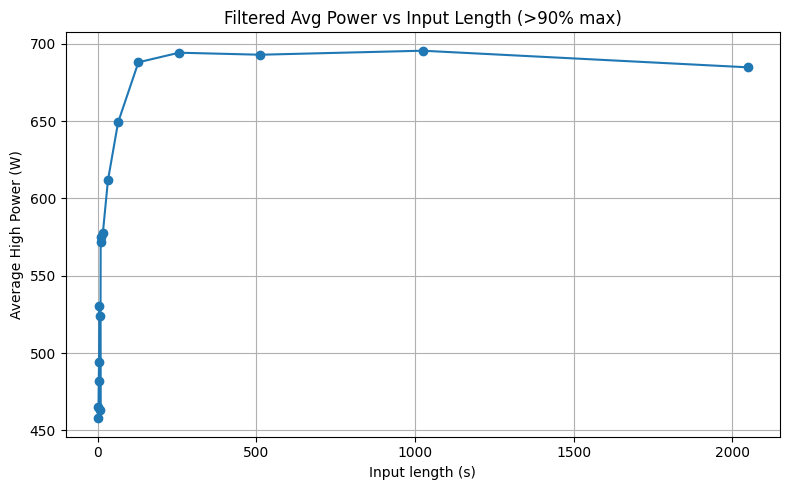

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

threshold_ratio = 0.9  # Seuil de filtrage (90% du max)
input_lengths = []
avg_high_powers = []

for file in os.listdir("./power_data/"):
    if file.endswith(".csv") and file.startswith("prefill_s"):
        s = int(file.split("_s")[1].split(".")[0])
        power_df = pd.read_csv(f"./power_data/{file}")

        max_power = power_df["power_w"].max()
        threshold = threshold_ratio * max_power

        # Ne garder que les puissances proches du max
        high_power_values = power_df[power_df["power_w"] >= threshold]["power_w"]

        if not high_power_values.empty:
            avg_power = high_power_values.mean()
            input_lengths.append(s)
            avg_high_powers.append(avg_power)

# Tri par longueur d'entrée
sorted_pairs = sorted(zip(input_lengths, avg_high_powers))
input_lengths, avg_high_powers = zip(*sorted_pairs)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(input_lengths, avg_high_powers, marker='o')
plt.xlabel("Input length (s)")
plt.ylabel("Average High Power (W)")
plt.title(f"Filtered Avg Power vs Input Length (>{int(threshold_ratio*100)}% max)")
plt.grid(True)
plt.tight_layout()
plt.show()


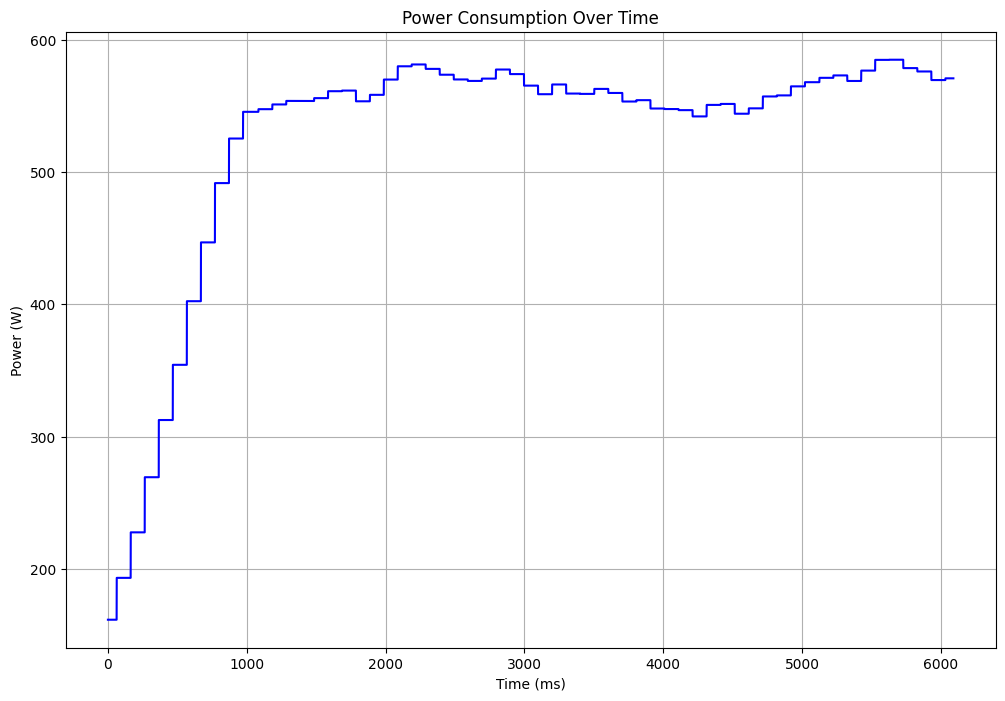

In [2]:
import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-09-16-39-35.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

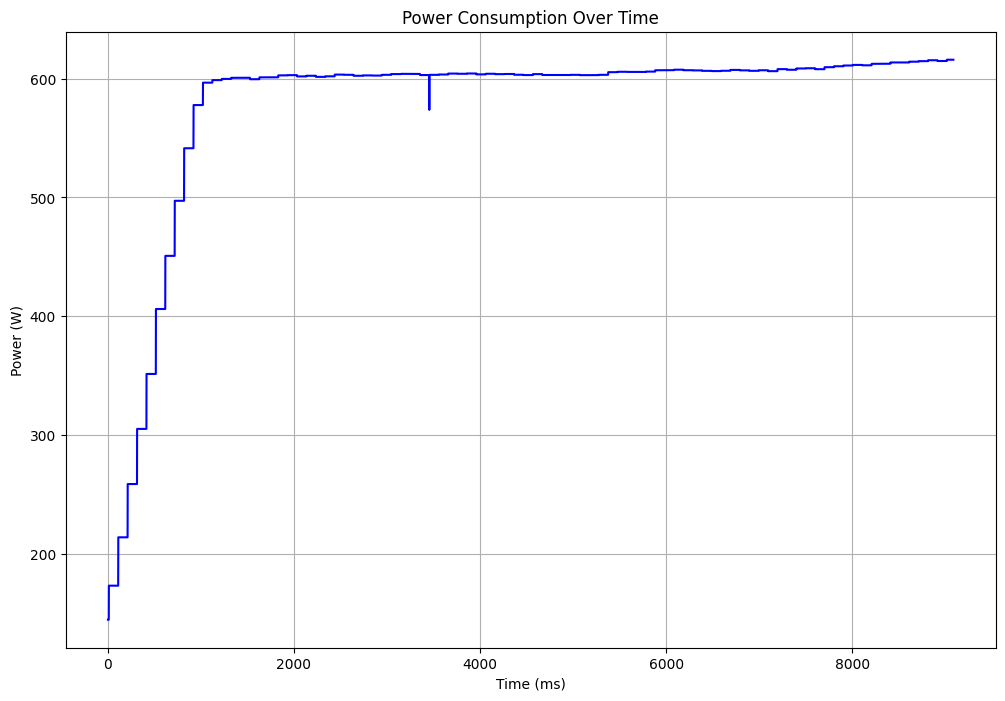

In [6]:
import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-09-16-46-29.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

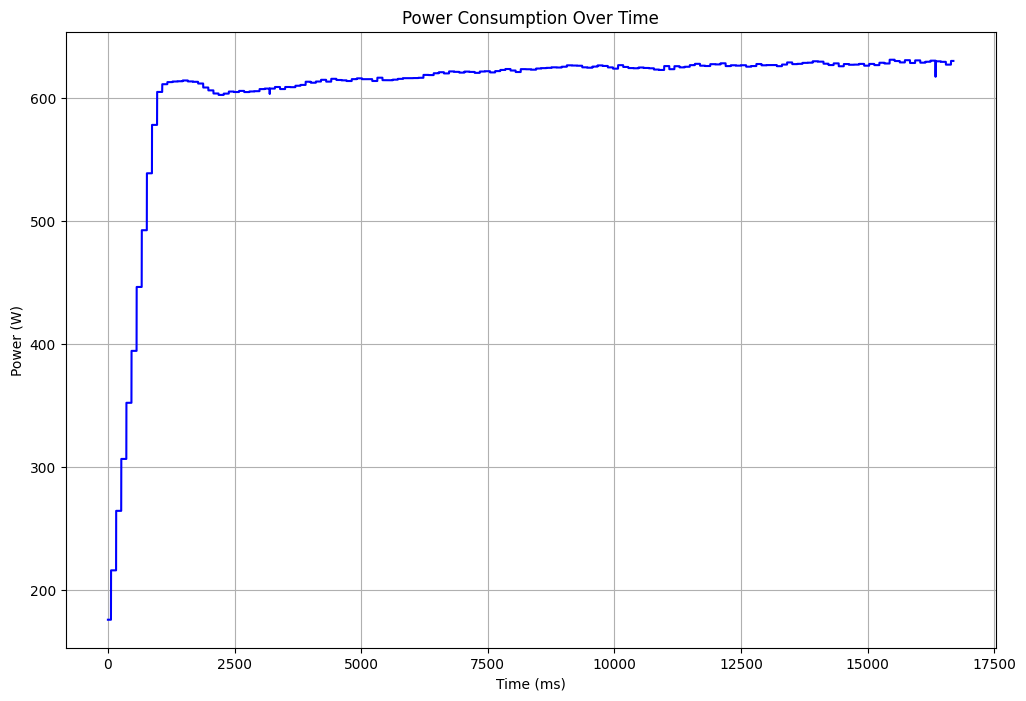

In [5]:
import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-09-16-49-29.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

### Power Decode phase

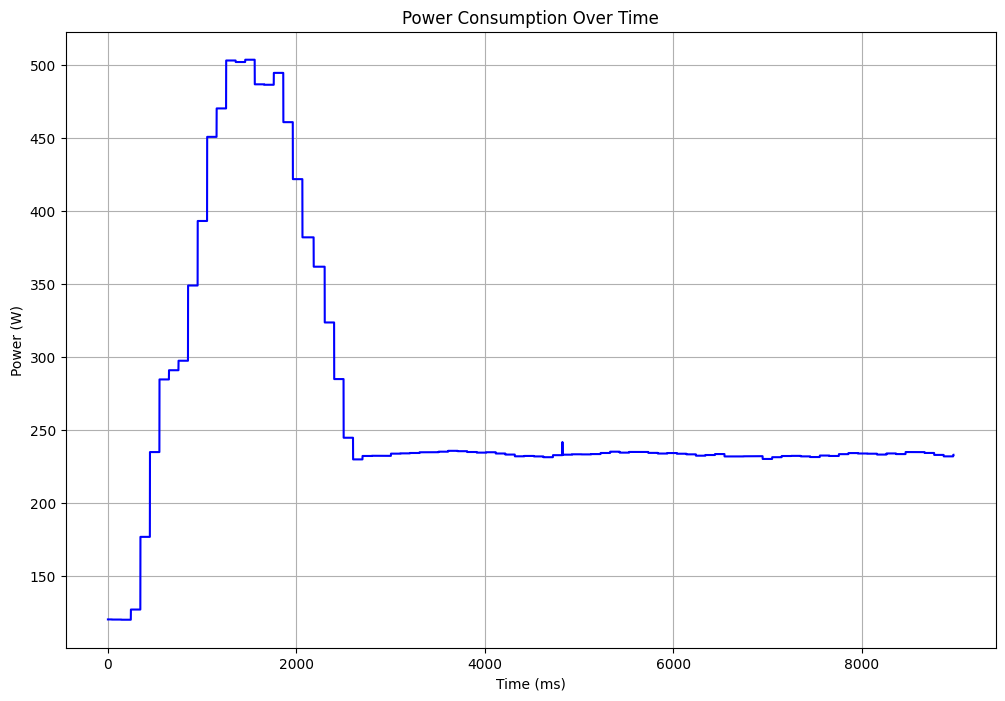

In [6]:

import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-03-15-50-37.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

['decode', '10_g1000.csv']
['decode', '16_g1000.csv']
['decode', '20_g1000.csv']
['decode', '6_g1000.csv']
['decode', '9_g1000.csv']
['decode', '18_g1000.csv']
['decode', '3_g1000.csv']
['decode', '12_g1000.csv']
['decode', '2_g1000.csv']
['decode', '8_g1000.csv']
['decode', '14_g1000.csv']
['decode', '7_g1000.csv']
['decode', '1_g1000.csv']
['decode', '4_g1000.csv']


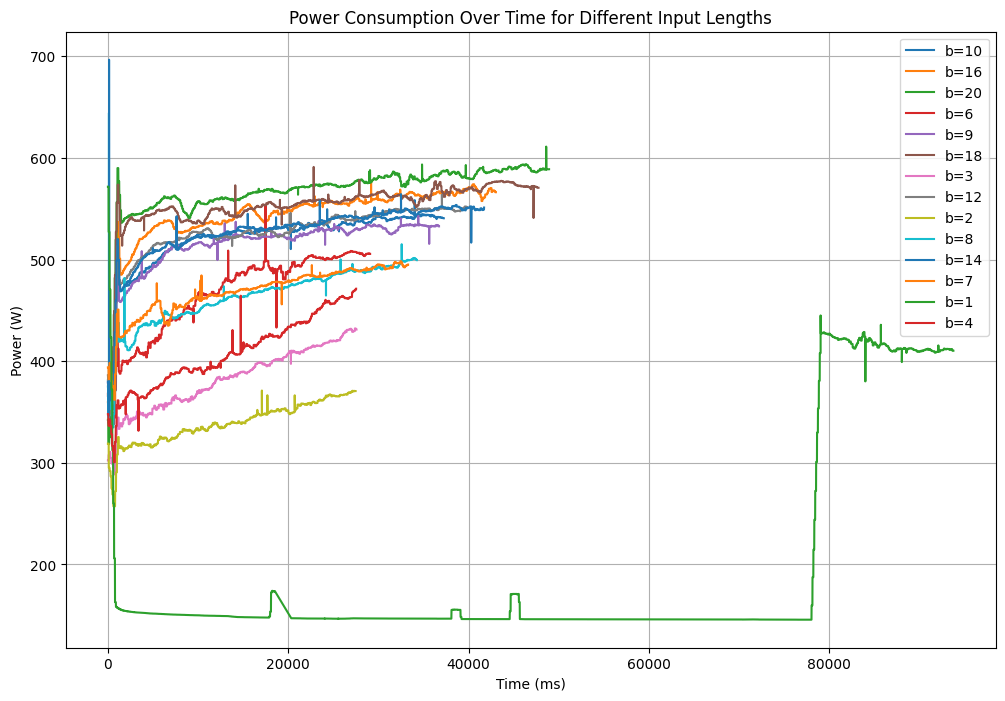

In [12]:
import os
plt.figure(figsize=(12, 8))
for file in os.listdir("./tmp/"):
    if file.endswith(".csv") and file.startswith("decode_b"):
        print(file.split("_b"))
        b = int(file.split("_b")[1].split("_")[0])
        power_df = pd.read_csv(f"./tmp/{file}")
        plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', label=f"b={b}")
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time for Different Input Lengths")
plt.legend()
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


['decode', '1_g3000.csv']
['decode', '18_g3000.csv']
['decode', '20_g3000.csv']
['decode', '7_g3000.csv']
['decode', '8_g3000.csv']
['decode', '12_g3000.csv']
['decode', '3_g3000.csv']
['decode', '9_g3000.csv']
['decode', '2_g3000.csv']
['decode', '16_g3000.csv']
['decode', '4_g3000.csv']
['decode', '6_g3000.csv']
['decode', '14_g3000.csv']
['decode', '10_g3000.csv']


/fsx/jdelavande/miniconda3/envs/benchlab/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


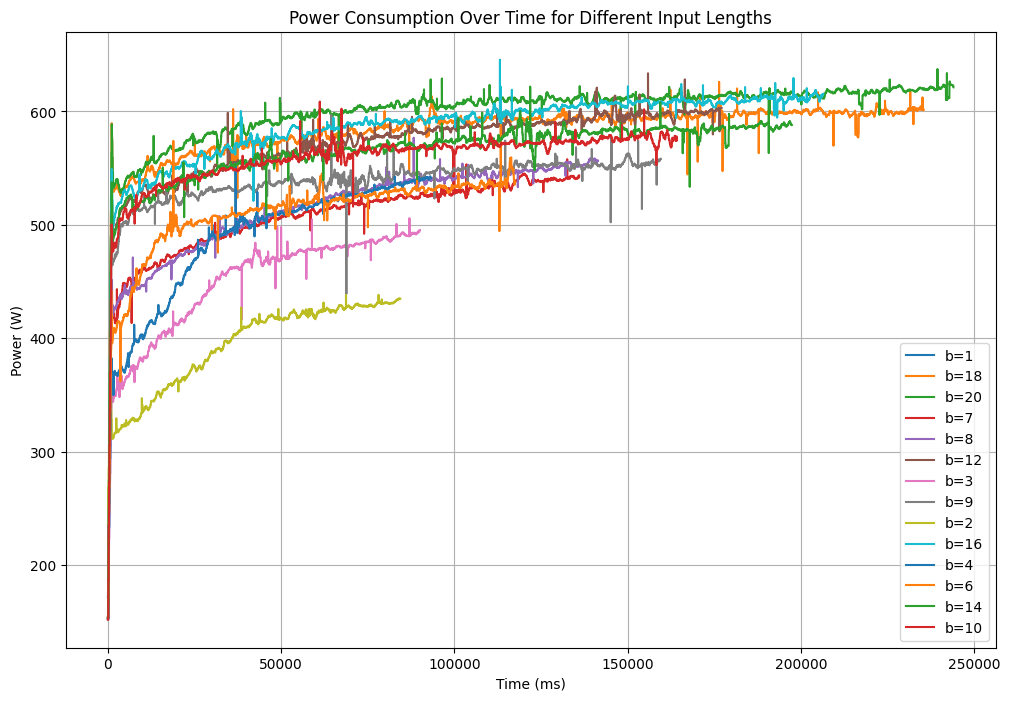

In [18]:
import os
plt.figure(figsize=(12, 8))
for file in os.listdir("./power_data/"):
    if file.endswith(".csv") and file.startswith("decode_b"):
        print(file.split("_b"))
        b = int(file.split("_b")[1].split("_")[0])
        power_df = pd.read_csv(f"./power_data/{file}")
        plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', label=f"b={b}")
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time for Different Input Lengths")
plt.legend()
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


['decode', '21_g3000.csv']
['decode', '28_g3000.csv']
['decode', '2_g3000.csv']
['decode', '27_g3000.csv']
['decode', '15_g3000.csv']
['decode', '10_g3000.csv']
['decode', '14_g3000.csv']
['decode', '9_g3000.csv']
['decode', '29_g3000.csv']
['decode', '19_g3000.csv']
['decode', '22_g3000.csv']
['decode', '5_g3000.csv']
['decode', '23_g3000.csv']
['decode', '25_g3000.csv']
['decode', '7_g3000.csv']
['decode', '12_g3000.csv']
['decode', '3_g3000.csv']
['decode', '31_g3000.csv']
['decode', '16_g3000.csv']
['decode', '26_g3000.csv']
['decode', '33_g3000.csv']
['decode', '6_g3000.csv']
['decode', '18_g3000.csv']
['decode', '4_g3000.csv']
['decode', '17_g3000.csv']
['decode', '11_g3000.csv']
['decode', '24_g3000.csv']
['decode', '1_g3000.csv']
['decode', '8_g3000.csv']
['decode', '13_g3000.csv']
['decode', '20_g3000.csv']
['decode', '32_g3000.csv']
['decode', '30_g3000.csv']


/fsx/jdelavande/miniconda3/envs/benchlab/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


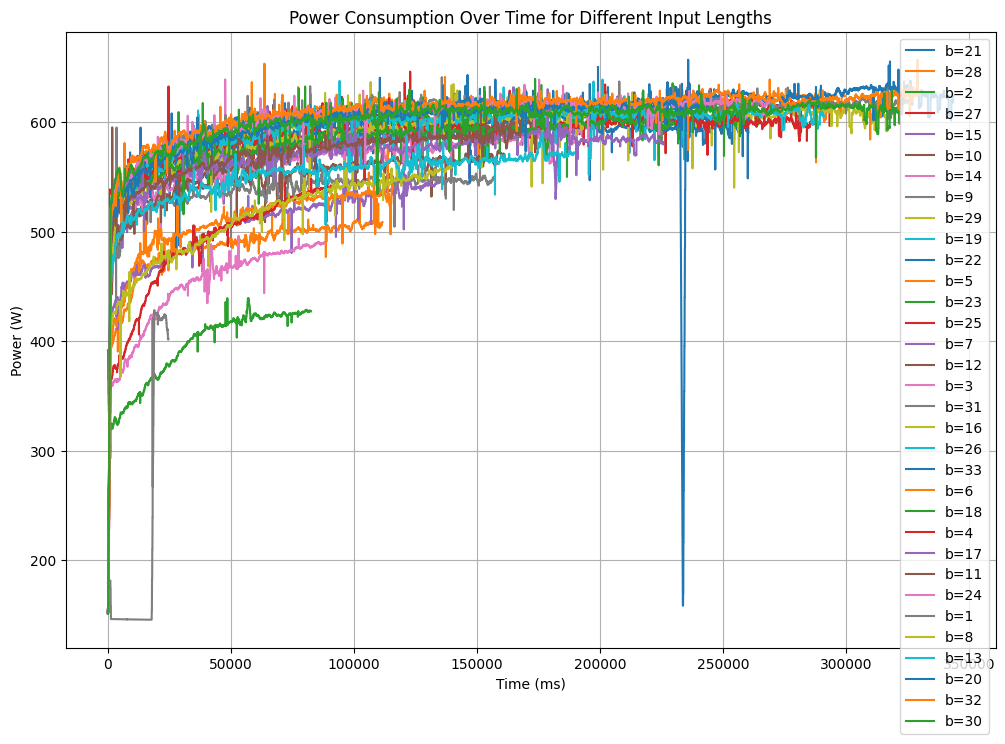

In [9]:
import os
plt.figure(figsize=(12, 8))
for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("decode_b"):
        print(file.split("_b"))
        b = int(file.split("_b")[1].split("_")[0])
        power_df = pd.read_csv(f"./power_data2/{file}")
        plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', label=f"b={b}")
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time for Different Input Lengths")
plt.legend()
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


/fsx/jdelavande/miniconda3/envs/benchlab/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


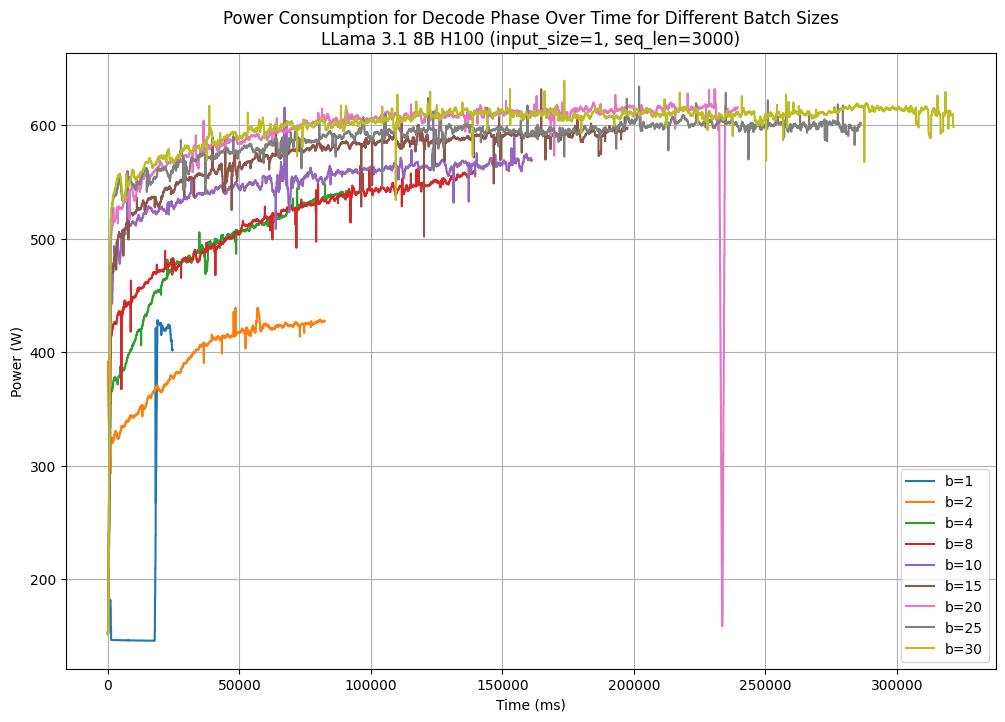

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
curves = []

for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("decode_b"):
        b = int(file.split("_b")[1].split("_")[0])
        if b in [1, 2, 4, 8, 10, 15, 20, 25, 30]:
            power_df = pd.read_csv(f"./power_data2/{file}")
            x = power_df["time_ms"]
            y = power_df["power_w"]
            curves.append((b, x, y))

# Trier les courbes par valeur croissante de b
curves.sort(key=lambda tup: tup[0])

# Tracer après le tri
for b, x, y in curves:
    plt.plot(x, y, linestyle='-', label=f"b={b}")

plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption for Decode Phase Over Time for Different Batch Sizes\nLLama 3.1 8B H100 (input_size=1, seq_len=3000)")
plt.legend()
plt.grid(True)
plt.show()


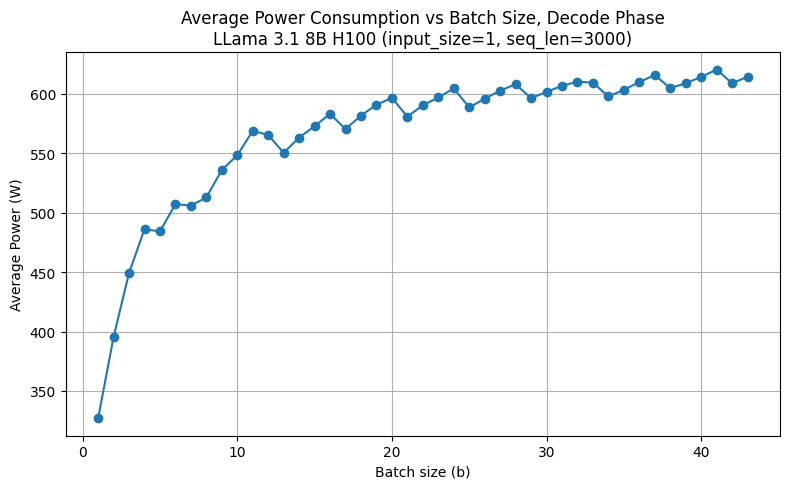

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt

batch_sizes = []
avg_powers = []

for file in os.listdir("./power_data2/"):
    if file.endswith(".csv") and file.startswith("decode_b"):
        b = int(file.split("_b")[1].split("_")[0])
        power_df = pd.read_csv(f"./power_data2/{file}")
        
        mean_power = power_df["power_w"].mean()
        
        batch_sizes.append(b)
        avg_powers.append(mean_power)

# Tri des résultats par taille de batch
sorted_pairs = sorted(zip(batch_sizes, avg_powers))
batch_sizes, avg_powers = zip(*sorted_pairs)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(batch_sizes, avg_powers, marker='o')
plt.xlabel("Batch size (b)")
plt.ylabel("Average Power (W)")
plt.title("Average Power Consumption vs Batch Size, Decode Phase\nLLama 3.1 8B H100 (input_size=1, seq_len=3000)")
plt.grid(True)
plt.tight_layout()
plt.show()


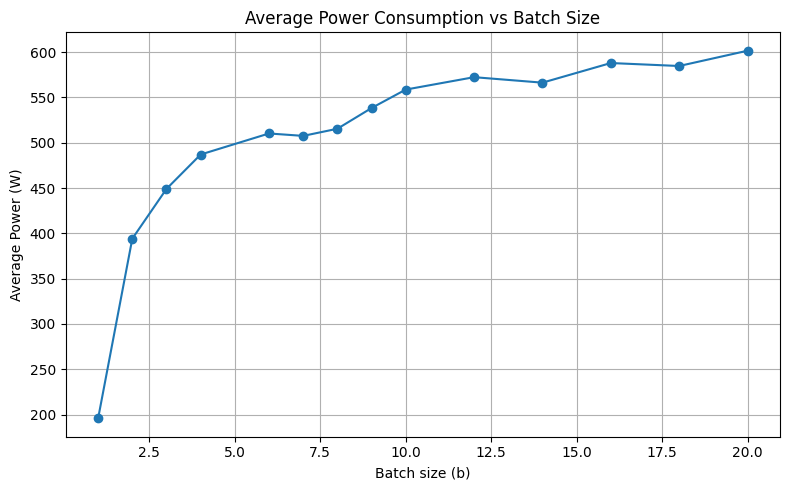

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt

batch_sizes = []
avg_powers = []

for file in os.listdir("./power_data/"):
    if file.endswith(".csv") and file.startswith("decode_b"):
        b = int(file.split("_b")[1].split("_")[0])
        power_df = pd.read_csv(f"./power_data/{file}")
        
        mean_power = power_df["power_w"].mean()
        
        batch_sizes.append(b)
        avg_powers.append(mean_power)

# Tri des résultats par taille de batch
sorted_pairs = sorted(zip(batch_sizes, avg_powers))
batch_sizes, avg_powers = zip(*sorted_pairs)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(batch_sizes, avg_powers, marker='o')
plt.xlabel("Batch size (b)")
plt.ylabel("Average Power (W)")
plt.title("Average Power Consumption vs Batch Size")
plt.grid(True)
plt.tight_layout()
plt.show()


### Power Decode phase with torch.compile (no idle time)

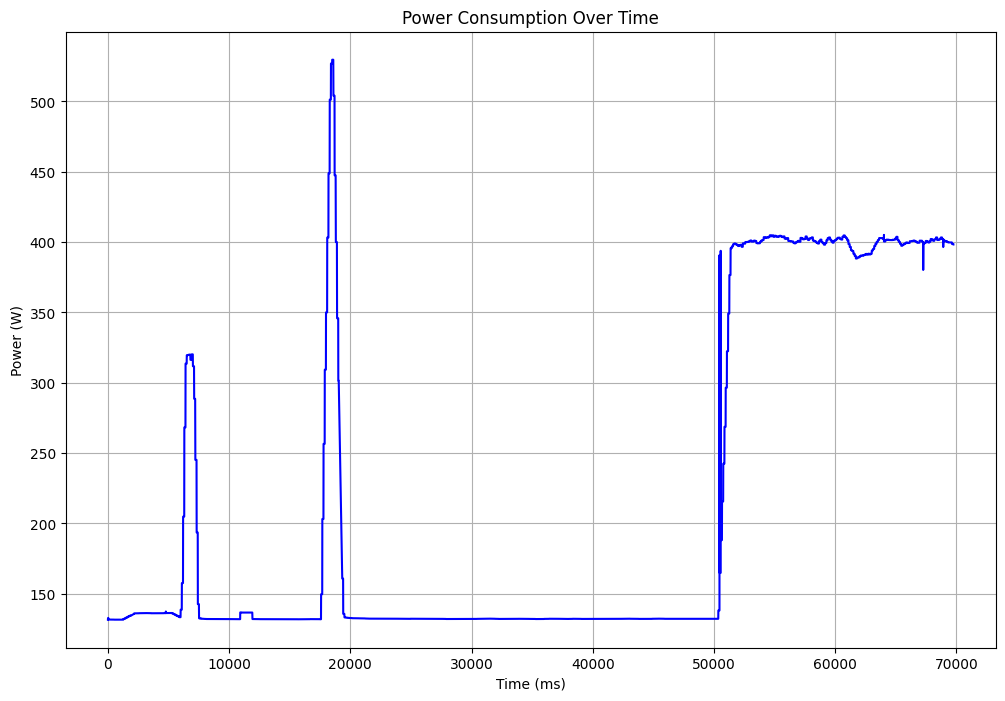

In [1]:

import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-09-14-56-49.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

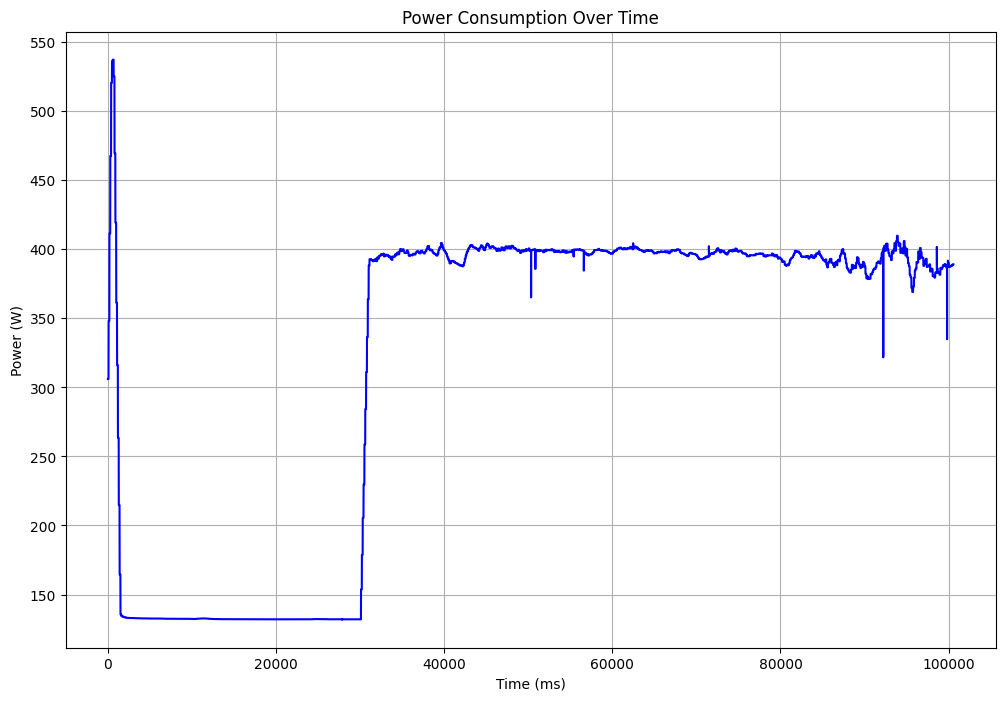

In [2]:

import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-09-15-06-14.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

#### batch_size = 10

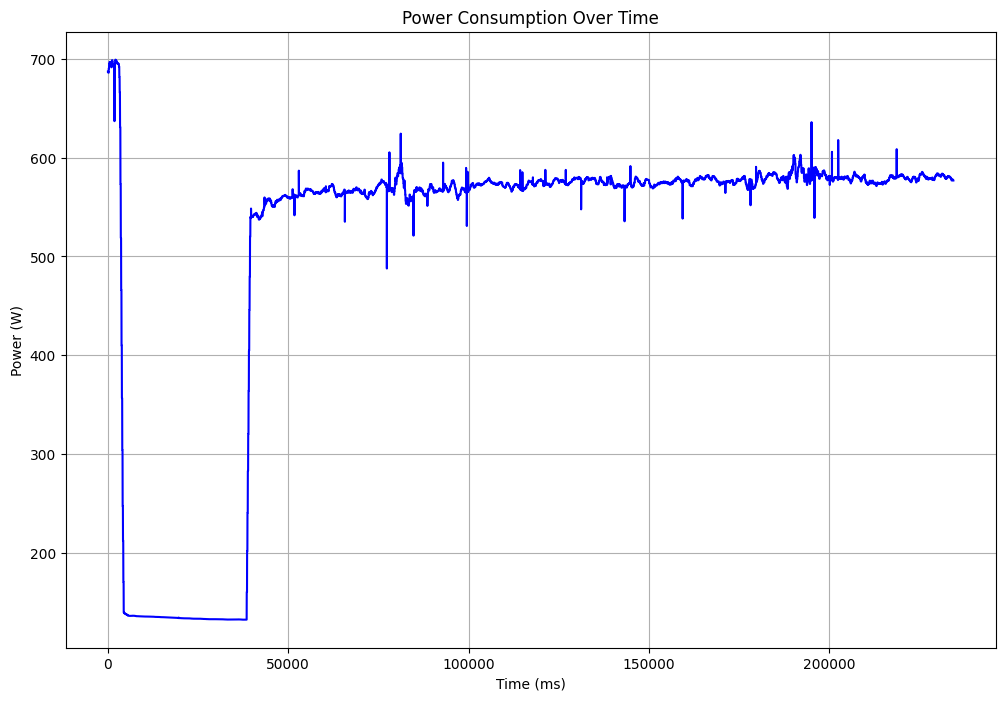

In [3]:

import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-09-15-17-35.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

#### batch = 10, seq_len = 10

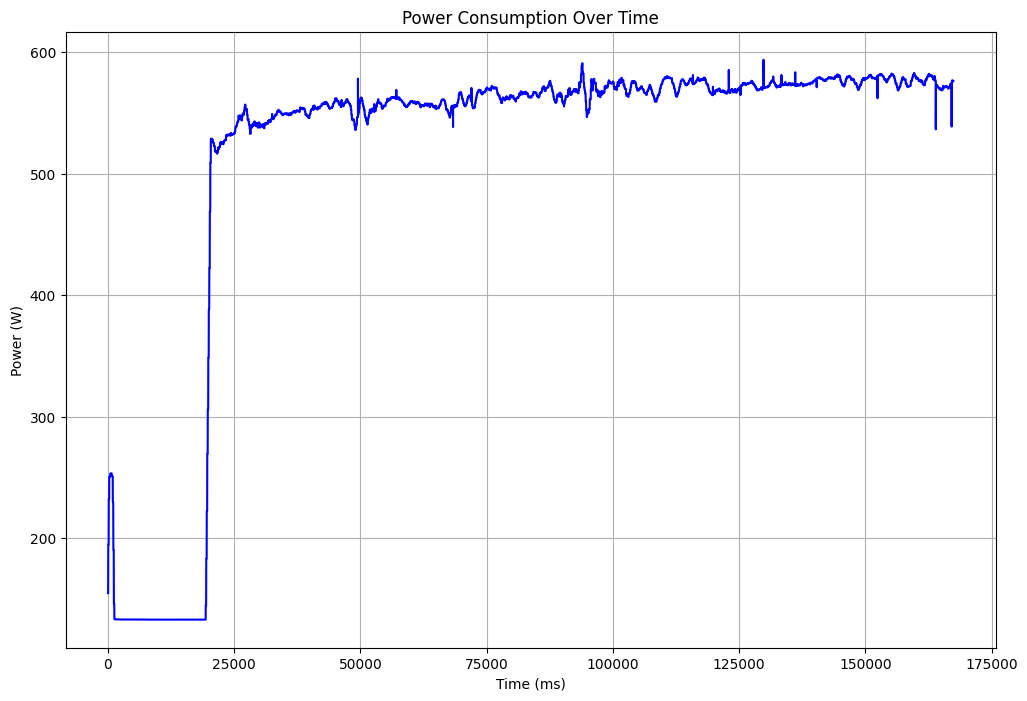

In [1]:

import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-09-15-42-16.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()